In [ ]:
from __future__ import annotations

# ---- stdlib ----
from google.colab import drive
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Tuple, List, Optional, Dict, Literal
from collections import defaultdict
from enum import Enum
import random, math, json, time, os

# ---- imaging / viz ----
from PIL import Image, ImageDraw, ImageFont, ImageFile
import matplotlib.pyplot as plt
import cv2

# ---- numeric / ML ----
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.functional as TVF
from torch.utils.data import DataLoader, Dataset

# ---- reporting ----
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize

# ---- type aliases / constants ----
PathLike = Path | str
RGB = tuple[int, int, int]

BALANCE_TARGET_COUNT_PER_CLASS = 2000
SPLIT_PERCENT_TEST = 0.2
SPLIT_PERCENT_VALIDATION = 0.2
SEED = 665

MAGIC_LEARNING_RATE = 0.000028

INSET = 10

#BATCH_SIZE = 32

NETWORK_SIZE = 224

# Image-space LAB L normalization defaults (baked in)
_L_TARGET_MEAN = 145.0
_L_TARGET_STD  = 40.0
_CLAHE_CLIP    = 2.0
_CLAHE_TILE    = (8, 8)

# Denoise defaults (baked in)
_DENOISE_H = 5
_DENOISE_H_COLOR = 5
_DENOISE_TEMPLATE_W = 7
_DENOISE_SEARCH_W = 21

# Model tensor normalization defaults (baked in)
_RESNET_MEAN = (0.485, 0.456, 0.406)
_RESNET_STD  = (0.229, 0.224, 0.225)
_EFFNET_MEAN = (0.485, 0.456, 0.406)
_EFFNET_STD  = (0.229, 0.224, 0.225)

# ---- repro ----
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

torch.set_default_dtype(torch.float32)
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

print("🟢 Modules loaded.")

🟢 Modules loaded.


In [ ]:
# This will handle permissions.
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Every time, unzip the data set and save to the notebook's ephemeral workspace.
!unzip -q /content/drive/MyDrive/leuko_fatty_256.zip -d /content/leuko_fatty_256

In [ ]:
DATA_ROOT = Path("/content/leuko_fatty_256")
if (DATA_ROOT / "leuko_fatty_256").is_dir():
    DATA_ROOT = DATA_ROOT / "leuko_fatty_256"

jpg_files = list(DATA_ROOT.rglob("*.jpg"))
valid_count = corrupt_count = 0
min_width = min_height = 2048; max_width = max_height = 0
found_any = False

ImageFile.LOAD_TRUNCATED_IMAGES = True
for img_path in jpg_files:
    try:
        with Image.open(img_path) as img:
            w, h = img.size; found_any = True; valid_count += 1
            min_width = min(min_width, w); min_height = min(min_height, h)
            max_width = max(max_width, w); max_height = max(max_height, h)
    except Exception:
        corrupt_count += 1

if not found_any:
    print("⚠️ 0 images, no valid images found.")
else:
    if corrupt_count: print(f"⚠️ {corrupt_count} corrupt image files.")
    if (min_width, min_height) == (max_width, max_height):
        print(f"🟢 {valid_count} images with ubiquitous dimensions, {min_width} x {min_height} pixels.")
    else:
        print(f"🟡 {valid_count} images of mixed dimensions\n   ({min_width} to {max_width}) x ({min_height} to {max_height}) pixels.")

ImageFile.LOAD_TRUNCATED_IMAGES = False

@dataclass(frozen=True)
class Augmentation:
    flip_horizontal: bool
    rotation_degrees: int
    translate_x: int
    translate_y: int
    brightness_factor: float = 1.0
    contrast_factor: float = 1.0
    saturation_factor: float = 1.0

def _validate_rgb(rgb: RGB) -> RGB:
    r, g, b = int(rgb[0]), int(rgb[1]), int(rgb[2])
    if not (0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255):
        raise ValueError(f"background_rgb out of range: {rgb}")
    return (r, g, b)

def _apply_geometry_pil(image: Image.Image, augmentation: Augmentation, background_rgb: RGB) -> Image.Image:
    out = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT) if augmentation.flip_horizontal else image
    r = augmentation.rotation_degrees % 360
    if r == 90: out = out.transpose(Image.Transpose.ROTATE_90)
    elif r == 180: out = out.transpose(Image.Transpose.ROTATE_180)
    elif r == 270: out = out.transpose(Image.Transpose.ROTATE_270)
    elif r != 0: raise ValueError("rotation_degrees must be one of {0, 90, 180, 270}")
    if out.mode != "RGB": out = out.convert("RGB")

    arr = np.asarray(out); h, w, _ = arr.shape
    dx, dy = augmentation.translate_x, augmentation.translate_y
    out_arr = np.empty((h, w, 3), dtype=arr.dtype); out_arr[:, :] = np.array(background_rgb, dtype=arr.dtype)

    src_x0, src_y0 = max(0, -dx), max(0, -dy); src_x1, src_y1 = min(w, w - dx), min(h, h - dy)
    dst_x0, dst_y0 = max(0, dx), max(0, dy);   dst_x1, dst_y1 = dst_x0 + (src_x1 - src_x0), dst_y0 + (src_y1 - src_y0)
    if src_x1 > src_x0 and src_y1 > src_y0: out_arr[dst_y0:dst_y1, dst_x0:dst_x1] = arr[src_y0:src_y1, src_x0:src_x1]
    return Image.fromarray(out_arr)

def _apply_color_torch(image: Image.Image, augmentation: Augmentation) -> Image.Image:
    if image.mode != "RGB": image = image.convert("RGB")
    tensor = TVF.pil_to_tensor(image).to(dtype=torch.float32).div_(255.0)

    if augmentation.brightness_factor != 1.0: tensor = TVF.adjust_brightness(tensor, augmentation.brightness_factor)
    if augmentation.contrast_factor   != 1.0: tensor = TVF.adjust_contrast(tensor, augmentation.contrast_factor)
    if augmentation.saturation_factor != 1.0: tensor = TVF.adjust_saturation(tensor, augmentation.saturation_factor)

    tensor_u8 = torch.round(tensor.clamp(0.0, 1.0) * 255.0).clamp(0.0, 255.0).to(torch.uint8)
    return TVF.to_pil_image(tensor_u8)

def apply_augmentation(image: Image.Image, augmentation: Augmentation, background_rgb: RGB = (255, 255, 255)) -> Image.Image:
    background_rgb = _validate_rgb(background_rgb)
    dx, dy = augmentation.translate_x, augmentation.translate_y
    needs_geometry = augmentation.flip_horizontal or (augmentation.rotation_degrees % 360) != 0 or dx != 0 or dy != 0

    out = _apply_geometry_pil(image, augmentation, background_rgb) if needs_geometry else (image if image.mode == "RGB" else image.convert("RGB"))
    needs_color = augmentation.brightness_factor != 1.0 or augmentation.contrast_factor != 1.0 or augmentation.saturation_factor != 1.0
    return _apply_color_torch(out, augmentation) if needs_color else out

@dataclass(frozen=True)
class FileReference:
    path: Path
    def __init__(self, path: PathLike):
        object.__setattr__(self, "path", Path(path))

@dataclass(frozen=True)
class FileReferenceAndAugmentation:
    file_reference: FileReference
    augmentation: Optional[Augmentation]

class_dirs = sorted(p for p in DATA_ROOT.iterdir() if p.is_dir() and not p.name.startswith("__"))
class_names: List[str] = [p.name for p in class_dirs]; num_classes = len(class_names)
if num_classes == 0: raise RuntimeError(f"No class folders found under {DATA_ROOT}")

class_index_lut: Dict[str, int] = {name: i for i, name in enumerate(class_names)}
index_class_lut: Dict[int, str] = {i: name for name, i in class_index_lut.items()}

# quick sanity
assert len(class_index_lut) == num_classes and len(index_class_lut) == num_classes
for _name, _idx in class_index_lut.items(): assert index_class_lut[_idx] == _name

file_refs_by_class = defaultdict(list); all_file_refs: List[FileReference] = []
for class_dir in class_dirs:
    class_name = class_dir.name
    for p in sorted(class_dir.rglob("*.jpg")):
        if p.is_file() and p.suffix.lower() == ".jpg":
            ref = FileReference(path=p); file_refs_by_class[class_name].append(ref); all_file_refs.append(ref)

file_refs_by_class = dict(file_refs_by_class)

print("Total file references:", len(all_file_refs))
for name in class_names[:10]: print(f"{name:>20s}: {len(file_refs_by_class[name])}")


def _stable_u32(s: str) -> int:
    # python's built-in hash() is randomized per process; use a stable hash for reproducible splits
    import hashlib
    return int.from_bytes(hashlib.blake2b(s.encode("utf-8"), digest_size=4).digest(), "little")

def split_list_deterministic(items, seed):
    items = sorted(items, key=lambda fr: fr.path.as_posix())
    items = list(items)
    rng = random.Random(seed)
    rng.shuffle(items)
    n = len(items); n_test = int(n * SPLIT_PERCENT_TEST); n_val = int(n * SPLIT_PERCENT_VALIDATION); n_train = n - n_test - n_val

    # keep it sane for tiny classes
    if n and n_train <= 0:
        n_train = 1; leftover = n - n_train
        n_val = min(n_val, leftover); n_test = min(n_test, leftover - n_val)

    train = items[:n_train]; val = items[n_train:n_train + n_val]; test = items[n_train + n_val:n_train + n_val + n_test]
    return train, val, test

train_refs_by_class: Dict[str, List[FileReference]] = {}
val_refs_by_class: Dict[str, List[FileReference]] = {}
test_refs_by_class: Dict[str, List[FileReference]] = {}

for class_name in class_names:
    refs = file_refs_by_class.get(class_name, [])
    class_seed = _stable_u32(f"{SEED}|{class_name}")
    train, val, test = split_list_deterministic(refs, class_seed)
    train_refs_by_class[class_name] = train; val_refs_by_class[class_name] = val; test_refs_by_class[class_name] = test

holdout_refs_by_class: Dict[str, List[FileReference]] = {c: (val_refs_by_class[c] + test_refs_by_class[c]) for c in class_names}

def summarize_split(split_name: str, split_dict: Dict[str, List[FileReference]]):
    print(f"{split_name}: total={sum(len(v) for v in split_dict.values())}")

summarize_split("train", train_refs_by_class); summarize_split("val", val_refs_by_class)
summarize_split("test", test_refs_by_class); summarize_split("holdout(val+test)", holdout_refs_by_class)

_example_class = class_names[0]
print("\nExample class:", _example_class)
print(" train:", len(train_refs_by_class[_example_class]))
print(" val  :", len(val_refs_by_class[_example_class]))
print(" test :", len(test_refs_by_class[_example_class]))

BRIGHTNESS_MIN, BRIGHTNESS_MAX = 0.90, 1.10
CONTRAST_MIN,   CONTRAST_MAX   = 0.90, 1.10
SATURATION_MIN, SATURATION_MAX = 0.95, 1.05
JITTER_CHOICES = [-5, 0, 5]
ROTATION_CHOICES = [0, 90, 180, 270]

def make_random_augmentation(_rng: random.Random) -> Augmentation:
    return Augmentation(
        flip_horizontal=_rng.choice([False, True]),
        rotation_degrees=_rng.choice(ROTATION_CHOICES),
        translate_x=_rng.choice(JITTER_CHOICES),
        translate_y=_rng.choice(JITTER_CHOICES),
        brightness_factor=_rng.uniform(BRIGHTNESS_MIN, BRIGHTNESS_MAX),
        contrast_factor=_rng.uniform(CONTRAST_MIN, CONTRAST_MAX),
        saturation_factor=_rng.uniform(SATURATION_MIN, SATURATION_MAX),
    )

train_augmented_by_class: Dict[str, List[FileReferenceAndAugmentation]] = {}
val_augmented_by_class: Dict[str, List[FileReferenceAndAugmentation]] = {}
test_augmented_by_class: Dict[str, List[FileReferenceAndAugmentation]] = {}
train_augmented_all: List[FileReferenceAndAugmentation] = []
val_augmented_all: List[FileReferenceAndAugmentation] = []
test_augmented_all: List[FileReferenceAndAugmentation] = []

def _build_balanced_train_items(class_name: str) -> List[FileReferenceAndAugmentation]:
    base_refs = train_refs_by_class.get(class_name, [])
    n = len(base_refs)
    items: List[FileReferenceAndAugmentation] = [
        FileReferenceAndAugmentation(file_reference=fr, augmentation=None)
        for fr in base_refs
    ]
    if n == 0:
        return items
    rng = random.Random(_stable_u32(f"{SEED}|balance|{class_name}"))
    if len(items) > BALANCE_TARGET_COUNT_PER_CLASS:
        rng.shuffle(items)
        items = items[:BALANCE_TARGET_COUNT_PER_CLASS]
    while len(items) < BALANCE_TARGET_COUNT_PER_CLASS:
        src_fr = rng.choice(base_refs)
        aug = make_random_augmentation(rng)
        items.append(FileReferenceAndAugmentation(file_reference=src_fr, augmentation=aug))
    return items

def _items_no_aug(refs: List[FileReference]) -> List[FileReferenceAndAugmentation]:
    return [FileReferenceAndAugmentation(file_reference=fr, augmentation=None) for fr in refs]

for class_name in class_names:
    # train
    train_items = _build_balanced_train_items(class_name)
    train_augmented_by_class[class_name] = train_items
    train_augmented_all.extend(train_items)

    train_aug = sum(1 for x in train_items if x.augmentation is not None)
    train_real = len(train_items) - train_aug
    train_total = len(train_items)

    # val
    val_refs = val_refs_by_class.get(class_name, [])
    val_items = _items_no_aug(val_refs)
    val_augmented_by_class[class_name] = val_items
    val_augmented_all.extend(val_items)

    # test
    test_refs = test_refs_by_class.get(class_name, [])
    test_items = _items_no_aug(test_refs)
    test_augmented_by_class[class_name] = test_items
    test_augmented_all.extend(test_items)

    # one consolidated line
    if train_total == 0:
        print(
            f"⚠️ {class_name}: "
            f"train=0 (cannot balance) | "
            f"val={len(val_items)} | "
            f"test={len(test_items)}"
        )
    else:
        print(
            f"✅ {class_name}: "
            f"train={train_total} (real={train_real}, aug={train_aug}) | "
            f"val={len(val_items)} | "
            f"test={len(test_items)}"
        )

print("\n--- Totals ---")
print("Total train items (balanced):", len(train_augmented_all))
print("Total val items:", len(val_augmented_all))
print("Total test items:", len(test_augmented_all))


class PreprocessingModePillow(Enum):
    LAB = "lab"
    REINHARD = "reinhard"

class PreprocessingModeTensor(Enum):
    RES_NET_50 = "res_net_50"
    EFFICIENT_NET = "efficient_net"

PreprocessingKind = Literal["none", "pillow", "tensor"]

@dataclass(frozen=True)
class PreprocessingMode:
    kind: PreprocessingKind
    pillow: Optional[PreprocessingModePillow] = None
    tensor: Optional[PreprocessingModeTensor] = None

    @staticmethod
    def none() -> "PreprocessingMode": return PreprocessingMode(kind="none")
    @staticmethod
    def pillow_mode(m: PreprocessingModePillow) -> "PreprocessingMode": return PreprocessingMode(kind="pillow", pillow=m)
    @staticmethod
    def tensor_mode(m: PreprocessingModeTensor) -> "PreprocessingMode": return PreprocessingMode(kind="tensor", tensor=m)
    def __post_init__(self) -> None:
        if self.kind == "none":
            if self.pillow is not None or self.tensor is not None: raise ValueError("none must not carry values")
        elif self.kind == "pillow":
            if self.pillow is None or self.tensor is not None: raise ValueError("pillow must carry pillow only")
        elif self.kind == "tensor":
            if self.tensor is None or self.pillow is not None: raise ValueError("tensor must carry tensor only")
        else:
            raise ValueError(f"Unknown kind: {self.kind!r}")

@dataclass(frozen=True)
class PreprocessConfig:
    preprocessing_mode: PreprocessingMode = PreprocessingMode.none()  # NOTE: call it
    clahe: bool = False
    denoise: bool = False

def crop_inset_and_resize(img: Image.Image) -> Image.Image:
    if img.mode != "RGB": img = img.convert("RGB")
    w, h = img.size; inset = int(max(0, INSET))
    if (w - 2 * inset) <= 1 or (h - 2 * inset) <= 1:
        s = max(1, min(w, h)); left = (w - s) // 2; top = (h - s) // 2; img = img.crop((left, top, left + s, top + s))
    else:
        img = img.crop((inset, inset, w - inset, h - inset))
    return img.resize((NETWORK_SIZE, NETWORK_SIZE), resample=Image.Resampling.BILINEAR)

def _apply_clahe(img: Image.Image) -> Image.Image:
    if img.mode != "RGB": img = img.convert("RGB")
    rgb = np.asarray(img); lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB); l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=float(_CLAHE_CLIP), tileGridSize=_CLAHE_TILE); l2 = clahe.apply(l)
    rgb2 = cv2.cvtColor(cv2.merge([l2, a, b]), cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb2)

def _apply_denoise(img: Image.Image) -> Image.Image:
    if img.mode != "RGB": img = img.convert("RGB")
    rgb = np.asarray(img); bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    den = cv2.fastNlMeansDenoisingColored(bgr, None, h=_DENOISE_H, hColor=_DENOISE_H_COLOR, templateWindowSize=_DENOISE_TEMPLATE_W, searchWindowSize=_DENOISE_SEARCH_W)
    return Image.fromarray(cv2.cvtColor(den, cv2.COLOR_BGR2RGB))

def _pillow_lab(img: Image.Image) -> Image.Image:
    # your existing LAB L-channel standardization (baked constants)
    if img.mode != "RGB": img = img.convert("RGB")
    rgb = np.asarray(img); lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32); l, a, b = cv2.split(lab)
    eps = 1e-6; l_mean = float(l.mean()); l_std = float(l.std()) + eps
    l = (l - l_mean) / l_std * _L_TARGET_STD + _L_TARGET_MEAN
    l = np.clip(l, 0, 255).astype(np.uint8)
    rgb_norm = cv2.cvtColor(cv2.merge([l, a.astype(np.uint8), b.astype(np.uint8)]), cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb_norm)

def _pillow_reinhard(img: Image.Image) -> Image.Image:
    if img.mode != "RGB": img = img.convert("RGB")
    rgb = np.asarray(img)
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L, A, B = cv2.split(lab)
    tL_mu, tL_sd = 165.0, 35.0
    tA_mu, tA_sd = 135.0, 12.0
    tB_mu, tB_sd = 140.0, 12.0
    eps = 1e-6
    sL_mu, sL_sd = float(L.mean()), float(L.std()) + eps
    sA_mu, sA_sd = float(A.mean()), float(A.std()) + eps
    sB_mu, sB_sd = float(B.mean()), float(B.std()) + eps
    L = (L - sL_mu) / sL_sd * tL_sd + tL_mu
    A = (A - sA_mu) / sA_sd * tA_sd + tA_mu
    B = (B - sB_mu) / sB_sd * tB_sd + tB_mu
    lab2 = cv2.merge([np.clip(L,0,255), np.clip(A,0,255), np.clip(B,0,255)]).astype(np.uint8)
    rgb2 = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb2)

def preprocess_image_pillow(img: Image.Image, mode: PreprocessingModePillow) -> Image.Image:
    if mode == PreprocessingModePillow.LAB: return _pillow_lab(img)
    if mode == PreprocessingModePillow.REINHARD: return _pillow_reinhard(img)
    raise ValueError(f"Unknown PreprocessingModePillow: {mode!r}")

def _tensor_resnet_50(x01: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(_RESNET_MEAN, dtype=torch.float32, device=x01.device)[:, None, None]
    std  = torch.tensor(_RESNET_STD,  dtype=torch.float32, device=x01.device)[:, None, None]
    return (x01 - mean) / std

def _tensor_efficient_net(x01: torch.Tensor) -> torch.Tensor:
    return x01 * 2.0 - 1.0

def preprocess_image_tensor(x01: torch.Tensor, mode: PreprocessingModeTensor) -> torch.Tensor:
    if mode == PreprocessingModeTensor.RES_NET_50: return _tensor_resnet_50(x01)
    if mode == PreprocessingModeTensor.EFFICIENT_NET: return _tensor_efficient_net(x01)
    raise ValueError(f"Unknown PreprocessingModeTensor: {mode!r}")

def image_from_file_reference(file_reference: FileReference) -> Image.Image:
    """Load an image from disk with no augmentation."""
    with Image.open(file_reference.path) as im:
        im = im.convert("RGB") if im.mode != "RGB" else im.copy()
    return im

def image_from_file_reference_augmented(fra: FileReferenceAndAugmentation) -> Image.Image:
    """Load an image and apply augmentation if present."""
    img = image_from_file_reference(fra.file_reference)
    return apply_augmentation(img, fra.augmentation) if fra.augmentation is not None else img

def tensor_to_pil(tensor: torch.Tensor) -> Image.Image:
    tensor = tensor.detach()
    tensor = torch.clamp(tensor, 0.0, 1.0)
    tensor_u8 = torch.round(tensor * 255.0).clamp(0.0, 255.0).to(torch.uint8)
    return TVF.to_pil_image(tensor_u8)

def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    if img.mode != "RGB":
        img = img.convert("RGB")
    return TVF.pil_to_tensor(img).to(dtype=torch.float32).div_(255.0)  # [C,H,W] in 0..1

class LeukocyteDataSet(Dataset):
    def __init__(
        self,
        items: List[FileReferenceAndAugmentation],
        class_index_lut: Dict[str, int],
        data_root: Optional[Path] = None,
        preprocess_config: Optional[PreprocessConfig] = None,
    ):
        self.items = items
        self.class_index_lut = class_index_lut
        self.data_root = data_root
        self.preprocess_config = preprocess_config

    def __len__(self) -> int:
        return len(self.items)

    def _class_name_from_path(self, p: Path) -> str:
        if self.data_root is None:
            return p.parent.name
        return p.relative_to(self.data_root).parts[0]

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        fra = self.items[idx]
        img = image_from_file_reference_augmented(fra)
        img = crop_inset_and_resize(img)
        cfg = self.preprocess_config
        if cfg is not None:
            if cfg.denoise:
                img = _apply_denoise(img)
            if cfg.clahe:
                img = _apply_clahe(img)

            m = cfg.preprocessing_mode
            if m.kind == "pillow":
                img = preprocess_image_pillow(img, m.pillow)  # type: ignore[arg-type]
            elif m.kind == "none" or m.kind == "tensor":
                pass
            else:
                raise ValueError(f"Bad preprocessing_mode.kind: {m.kind!r}")

        p = fra.file_reference.path
        class_name = self._class_name_from_path(p)
        class_index = self.class_index_lut[class_name]
        x = TVF.pil_to_tensor(img).to(dtype=torch.float32).div_(255.0)  # [C,H,W] in 0..1
        if cfg is not None:
            m = cfg.preprocessing_mode
            if m.kind == "tensor":
                x = preprocess_image_tensor(x, m.tensor)  # type: ignore[arg-type]
        return x.contiguous(), class_index

🟢 23953 images with ubiquitous dimensions, 288 x 288 pixels.
Total file references: 23953
            basophil: 616
          eosinophil: 2000
          hairy_cell: 2000
          lymphocyte: 2000
lymphocyte_large_granular: 1849
lymphocyte_neoplastic: 180
       metamyelocyte: 483
            monocyte: 2000
          myeloblast: 2000
           myelocyte: 747
train: total=14379
val: total=4787
test: total=4787
holdout(val+test): total=9574

Example class: basophil
 train: 370
 val  : 123
 test : 123
✅ basophil: train=2000 (real=370, aug=1630) | val=123 | test=123
✅ eosinophil: train=2000 (real=1200, aug=800) | val=400 | test=400
✅ hairy_cell: train=2000 (real=1200, aug=800) | val=400 | test=400
✅ lymphocyte: train=2000 (real=1200, aug=800) | val=400 | test=400
✅ lymphocyte_large_granular: train=2000 (real=1111, aug=889) | val=369 | test=369
✅ lymphocyte_neoplastic: train=2000 (real=108, aug=1892) | val=36 | test=36
✅ metamyelocyte: train=2000 (real=291, aug=1709) | val=96 | test=96
✅ m

Samples:
  /content/leuko_fatty_256/leuko_fatty_256/eosinophil/eosinophil_1911.jpg
  /content/leuko_fatty_256/leuko_fatty_256/neutrophil_segmented/neutrophil_segmented_1225.jpg
  /content/leuko_fatty_256/leuko_fatty_256/neutrophil_segmented/neutrophil_segmented_1754.jpg


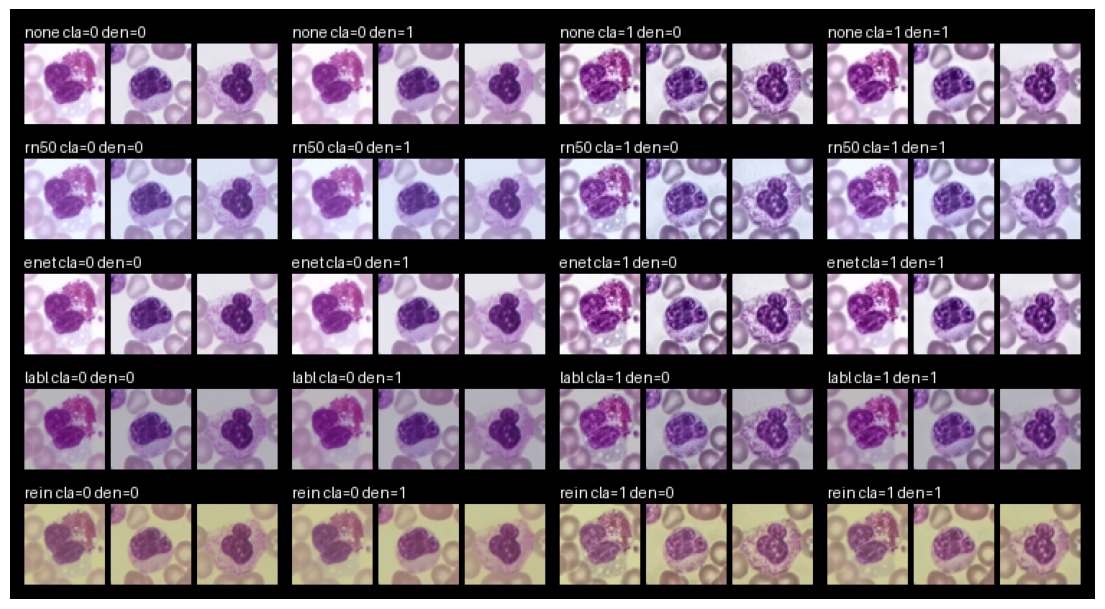

In [ ]:
# Peek at LeukocyteDataSet output under preprocessing configs. Optional cell. Skip if it's broken.
_seed=4242777; random.seed(_seed); np.random.seed(_seed); torch.manual_seed(_seed)
_thumb=56; _pad=4; _panel_pad=10; _label_h=14; _k=3; _font=ImageFont.load_default(); _cfgs=[(0,0),(0,1),(1,0),(1,1)]
_paths=[Path(p) for p in random.sample(jpg_files, k=min(_k,len(jpg_files)))]; print("Samples:"); [print(" ",p) for p in _paths]
_items=[FileReferenceAndAugmentation(FileReference(p), augmentation=None) for p in _paths]
_modes=[
    ("none", PreprocessConfig(PreprocessingMode.none())),
    ("rn50", PreprocessConfig(PreprocessingMode.tensor_mode(PreprocessingModeTensor.RES_NET_50))),
    ("enet", PreprocessConfig(PreprocessingMode.tensor_mode(PreprocessingModeTensor.EFFICIENT_NET))),
    ("labl", PreprocessConfig(PreprocessingMode.pillow_mode(PreprocessingModePillow.LAB))),
    ("rein", PreprocessConfig(PreprocessingMode.pillow_mode(PreprocessingModePillow.REINHARD))),
]
def _to_pil_disp(x: torch.Tensor, pm: PreprocessingMode) -> Image.Image:
    x=x.detach().cpu()
    if pm.kind=="tensor" and pm.tensor==PreprocessingModeTensor.RES_NET_50: x=((x+2.5)/5.0).clamp(0,1)
    elif pm.kind=="tensor" and pm.tensor==PreprocessingModeTensor.EFFICIENT_NET: x=((x+1.0)/2.0).clamp(0,1)
    return tensor_to_pil(x)
_cell_w=_k*_thumb+(_k-1)*_pad; _cell_h=_label_h+_thumb
_canvas_w=len(_cfgs)*_cell_w+(len(_cfgs)-1)*_panel_pad+2*_panel_pad
_canvas_h=len(_modes)*_cell_h+(len(_modes)-1)*_panel_pad+2*_panel_pad
_canvas=Image.new("RGB",(_canvas_w,_canvas_h),(0,0,0)); _draw=ImageDraw.Draw(_canvas)
for _r,(_row_label,_base_cfg) in enumerate(_modes):
    for _c,(_cla,_den) in enumerate(_cfgs):
        _cfg=PreprocessConfig(preprocessing_mode=_base_cfg.preprocessing_mode, clahe=bool(_cla), denoise=bool(_den))
        _ds=LeukocyteDataSet(items=_items, class_index_lut=class_index_lut, data_root=DATA_ROOT, preprocess_config=_cfg)
        _x,_ = next(iter(DataLoader(_ds, batch_size=_k, shuffle=False, num_workers=0)))
        _x0=_panel_pad+_c*(_cell_w+_panel_pad); _y0=_panel_pad+_r*(_cell_h+_panel_pad)
        _draw.text((_x0,_y0),f"{_row_label} cla={_cla} den={_den}",fill=(255,255,255),font=_font)
        for _i in range(_x.shape[0]):
            _pil=_to_pil_disp(_x[_i], _cfg.preprocessing_mode).resize((_thumb,_thumb), Image.Resampling.BILINEAR)
            _canvas.paste(_pil, (_x0+_i*(_thumb+_pad), _y0+_label_h))
plt.figure(figsize=(14, max(4, len(_modes)*1.8))); plt.imshow(_canvas); plt.axis("off"); plt.show()

In [ ]:

# STARTING HERE, this is other code, not from
# the new notebook. The above code is from new notebook.

# let's not rename these?
train_items = train_augmented_all
val_items   = val_augmented_all
test_items  = test_augmented_all

# we will create train_data_set in the training loop?
# this should be hardened against tuning batch size
preprocess_config = PreprocessConfig(
    preprocessing_mode=PreprocessingMode.pillow_mode(
        PreprocessingModePillow.REINHARD
    ),
    clahe=False,
    denoise=False,
)

train_data_set = LeukocyteDataSet(train_items, class_index_lut, DATA_ROOT, preprocess_config=preprocess_config)
val_data_set   = LeukocyteDataSet(val_items,   class_index_lut, DATA_ROOT, preprocess_config=preprocess_config)
test_data_set  = LeukocyteDataSet(test_items,  class_index_lut, DATA_ROOT, preprocess_config=preprocess_config)

PIN_MEMORY = False
NUM_WORKERS = 0

class SmallCuteCNN_14(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.2, stem: int = 32):
        super().__init__()

        def conv_bn_act(in_ch, out_ch, k=3, p=1):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.SiLU(inplace=True),
            )

        c1 = stem          # 32
        c2 = stem * 2      # 64
        c3 = stem * 4      # 128
        c4 = stem * 8      # 256

        self.features = nn.Sequential(
            # 224 -> 224
            conv_bn_act(3,  c1),      # 224
            nn.MaxPool2d(2),          # 224 -> 112

            # 112 -> 112
            conv_bn_act(c1, c2),      # 112
            nn.MaxPool2d(2),          # 112 -> 56

            # 56 -> 56
            conv_bn_act(c2, c3),      # 56
            nn.MaxPool2d(2),          # 56 -> 28

            # 28 -> 28
            conv_bn_act(c3, c4),      # 28
            conv_bn_act(c4, c4),      # 28
            nn.MaxPool2d(2),          # 28 -> 14
        )

        flat_dim = c4 * 14 * 14

        self.head = nn.Sequential(
            nn.Flatten(1),
            nn.Linear(flat_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        return self.head(x)


@dataclass(frozen=True)
class TrainStats:
    loss: float
    acc: float

@dataclass(frozen=True)
class EpochStats:
    epoch: int
    train_loss: float; train_acc: float
    val_loss: Optional[float] = None; val_acc: Optional[float] = None
    test_loss: Optional[float] = None; test_acc: Optional[float] = None
    lr: Optional[float] = None
    seconds: Optional[float] = None

def class_counts_from_items(
    items: List[FileReferenceAndAugmentation],
    class_index_lut: Dict[str, int],
    num_classes: int,
    data_root: Optional[Path] = None,
) -> torch.Tensor:
    counts = torch.zeros(num_classes, dtype=torch.long)
    for fra in items:
        p = fra.file_reference.path
        class_name = (p.relative_to(data_root).parts[0] if data_root is not None else p.parent.name)
        counts[class_index_lut[class_name]] += 1
    return counts

def get_device() -> torch.device:
    if torch.cuda.is_available(): return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
NUM_CLASSES = len(class_index_lut)

print("Device:", DEVICE)
print("Num classes:", NUM_CLASSES)

NameError: name 'train_augmented_all' is not defined

In [ ]:
def fire_epoch(
    *,
    device: torch.device,
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: Optional[torch.optim.Optimizer],
    is_train: bool,
) -> TrainStats:
    model.train() if is_train else model.eval()
    if is_train and optimizer is None: raise ValueError("optimizer must not be None when is_train=True")

    total_loss = 0.0; correct = 0; total = 0
    ctx = torch.enable_grad() if is_train else torch.inference_mode()

    with ctx:
        for xb, yb in loader:
            xb = xb.to(device); yb = yb.to(device)
            if is_train: optimizer.zero_grad(set_to_none=True)

            logits = model(xb); loss = criterion(logits, yb)
            if is_train: loss.backward(); optimizer.step()

            bs = int(yb.numel()); total += bs
            total_loss += float(loss.item()) * bs
            correct += int((logits.argmax(dim=1) == yb).sum().item())

    return TrainStats(loss=total_loss / max(1, total), acc=correct / max(1, total))

def train_one_epoch(*, device: torch.device, model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module) -> TrainStats:
    return fire_epoch(device=device, model=model, loader=loader, criterion=criterion, optimizer=optimizer, is_train=True)

def eval_one_epoch(*, device: torch.device, model: nn.Module, loader: DataLoader, criterion: nn.Module) -> TrainStats:
    return fire_epoch(device=device, model=model, loader=loader, criterion=criterion, optimizer=None, is_train=False)

def _append_jsonl(path: Path, row: Dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(row) + "\n")

def _load_jsonl(path: Path) -> list[Dict]:
    if not path.exists():
        return []
    out: list[Dict] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                out.append(json.loads(line))
    return out

def ckpt_path(models_dir: Path, epoch: int) -> Path:
    return models_dir / f"train_model_{epoch:04d}.pt"

def save_checkpoint(path: Path, *, model: nn.Module, optimizer: torch.optim.Optimizer, classes: list[str], epoch: int) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": int(epoch),
            "classes": classes,
            "arch": model.__class__.__name__,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        },
        path,
    )

def load_checkpoint_into_existing_strict(path: Path, *, model: nn.Module, optimizer: torch.optim.Optimizer, device: torch.device) -> int:
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    if "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    return int(ckpt.get("epoch", 0))


def train_loop_iteration(
    *,
    epoch: int,
    device: torch.device,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    loader_train: DataLoader,
    loader_val: Optional[DataLoader],
) -> Tuple[Dict, Dict]:
    """
    Runs exactly ONE epoch:
      - train epoch
      - optional val epoch
    Returns:
      train_stats_row: minimal row
      epoch_stats_row: richer row (train+val+lr+seconds)
    """
    t0 = time.time()
    tr = train_one_epoch(device=device, model=model, loader=loader_train, optimizer=optimizer, criterion=criterion)
    va = None
    if loader_val is not None:
        va = eval_one_epoch(device=device, model=model, loader=loader_val, criterion=criterion)
    secs = time.time() - t0
    lr = float(optimizer.param_groups[0].get("lr", 0.0))
    train_stats_row = {
        "epoch": int(epoch),
        "loss": float(tr.loss),
        "acc": float(tr.acc),
    }
    epoch_stats_row = {
        "epoch": int(epoch),
        "train_loss": float(tr.loss),
        "train_acc": float(tr.acc),
        "val_loss": (float(va.loss) if va else None),
        "val_acc":  (float(va.acc)  if va else None),
        "lr": float(lr),
        "seconds": float(secs),
    }
    return train_stats_row, epoch_stats_row



In [ ]:

# HERE, we want to use cosine decay.
# I just want to, in each loop, print the initial learn rate and the adjusted learn rate...

# fish up the best learning rate.
learn_rates = [
    MAGIC_LEARNING_RATE
    ]
#batch_sizes = [8, 12, 16, 24]
#weight_decays = [1e-5, 3e-5, 1e-4]

batch_sizes = [12]
weight_decays = [
    0.0,
    0.00005,
    0.0001,
    0.0005,
    0.001,
    0.0025,
    0.005,
    0.0075,
    0.01
]

for BATCH_SIZE in batch_sizes:
  for weight_decay in weight_decays:
    for learning_rate in learn_rates:

      print(f"Starting Pass, batch_size={BATCH_SIZE}, weight_decay={weight_decay}, learning_rate={learning_rate}")

      train_loader = DataLoader(
          train_data_set, batch_size=BATCH_SIZE,
          shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
      )

      val_loader = DataLoader(
          val_data_set, batch_size=BATCH_SIZE,
          shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
      )

      TRAIN_EPOCH_START = None    # e.g. 6 means "next epoch to run is 6"
      TRAIN_EPOCH_END   = 20      # inclusive

      models_dir = Path("models/run_dualbranch_reinhard_224_flatten")
      models_dir.mkdir(parents=True, exist_ok=True)

      train_stats_path = models_dir / "train_stats.jsonl"
      epoch_stats_path = models_dir / "epoch_stats.jsonl"

      train_stats_list = []
      epoch_stats_list = []

      # ---- build model/optimizer (fresh objects, then optionally load state into them) ----
      model = SmallCuteCNN_14(NUM_CLASSES).to(DEVICE)
      optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      _train_loop_start_epoch = 1
      train_stats_list = []
      epoch_stats_list = []

      criterion = nn.CrossEntropyLoss()

      for epoch in range(_train_loop_start_epoch, TRAIN_EPOCH_END + 1):
          train_row, epoch_row = train_loop_iteration(
              epoch=epoch,
              device=DEVICE,
              model=model,
              optimizer=optimizer,
              criterion=criterion,
              loader_train=train_loader,
              loader_val=val_loader,
          )

          train_stats_list.append(train_row)
          epoch_stats_list.append(epoch_row)

          score_acc = (
              epoch_row["val_acc"]
              if epoch_row["val_acc"] is not None
              else train_row["acc"]
          )

          msg = (
              f"@ lr = {learning_rate:.8f}, "
              f"batch = {BATCH_SIZE}, "
              f"w_decay = {weight_decay:.8f}, "
              f"epoch {epoch:02d} | "
              f"tr {train_row['loss']:.4f}/{train_row['acc']:.4f}"
          )
          if epoch_row["val_loss"] is not None:
              msg += f" | va {epoch_row['val_loss']:.4f}/{epoch_row['val_acc']:.4f}"
          msg += f" | lr {epoch_row['lr']:.8f} | {epoch_row['seconds']:.1f}s"
          print(msg)

Starting Pass, batch_size=12, weight_decay=0.0, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 01 | tr 1.0179/0.6622 | va 0.5727/0.8195 | lr 0.00002800 | 237.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 02 | tr 0.5388/0.8160 | va 0.4916/0.8381 | lr 0.00002800 | 236.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 03 | tr 0.3838/0.8663 | va 0.4558/0.8540 | lr 0.00002800 | 236.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 04 | tr 0.2853/0.9023 | va 0.4240/0.8611 | lr 0.00002800 | 236.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 05 | tr 0.2173/0.9255 | va 0.4420/0.8613 | lr 0.00002800 | 237.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 06 | tr 0.1596/0.9461 | va 0.4327/0.8699 | lr 0.00002800 | 237.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 07 | tr 0.1184/0.9614 | va 0.4577/0.8663 | lr 0.00002800 | 238.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, ep

In [ ]:
# fish up the best learning rate.
learn_rates = [
    MAGIC_LEARNING_RATE
    ]
#batch_sizes = [8, 12, 16, 24]
#weight_decays = [1e-5, 3e-5, 1e-4]

batch_sizes = [12]
weight_decays = [
    #0.0,
    #0.00005,
    #0.0001,
    #0.0005,
    0.001,
    0.0025,
    0.005,
    0.0075,
    0.01,
    0.015,
    0.02,
    0.025,
    0.03
]

for BATCH_SIZE in batch_sizes:
  for weight_decay in weight_decays:
    for learning_rate in learn_rates:

      print(f"Starting Pass, batch_size={BATCH_SIZE}, weight_decay={weight_decay}, learning_rate={learning_rate}")

      train_loader = DataLoader(
          train_data_set, batch_size=BATCH_SIZE,
          shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
      )

      val_loader = DataLoader(
          val_data_set, batch_size=BATCH_SIZE,
          shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
      )

      TRAIN_EPOCH_START = None    # e.g. 6 means "next epoch to run is 6"
      TRAIN_EPOCH_END   = 20      # inclusive

      models_dir = Path("models/run_dualbranch_reinhard_224_flatten")
      models_dir.mkdir(parents=True, exist_ok=True)

      train_stats_path = models_dir / "train_stats.jsonl"
      epoch_stats_path = models_dir / "epoch_stats.jsonl"

      train_stats_list = []
      epoch_stats_list = []

      # ---- build model/optimizer (fresh objects, then optionally load state into them) ----
      model = SmallCuteCNN_14(NUM_CLASSES).to(DEVICE)
      optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      _train_loop_start_epoch = 1
      train_stats_list = []
      epoch_stats_list = []

      criterion = nn.CrossEntropyLoss()

      for epoch in range(_train_loop_start_epoch, TRAIN_EPOCH_END + 1):
          train_row, epoch_row = train_loop_iteration(
              epoch=epoch,
              device=DEVICE,
              model=model,
              optimizer=optimizer,
              criterion=criterion,
              loader_train=train_loader,
              loader_val=val_loader,
          )

          train_stats_list.append(train_row)
          epoch_stats_list.append(epoch_row)

          score_acc = (
              epoch_row["val_acc"]
              if epoch_row["val_acc"] is not None
              else train_row["acc"]
          )

          msg = (
              f"@ lr = {learning_rate:.8f}, "
              f"batch = {BATCH_SIZE}, "
              f"w_decay = {weight_decay:.8f}, "
              f"epoch {epoch:02d} | "
              f"tr {train_row['loss']:.4f}/{train_row['acc']:.4f}"
          )
          if epoch_row["val_loss"] is not None:
              msg += f" | va {epoch_row['val_loss']:.4f}/{epoch_row['val_acc']:.4f}"
          msg += f" | lr {epoch_row['lr']:.8f} | {epoch_row['seconds']:.1f}s"
          print(msg)

Starting Pass, batch_size=12, weight_decay=0.001, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 01 | tr 1.0171/0.6611 | va 0.5674/0.8183 | lr 0.00002800 | 158.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 02 | tr 0.5397/0.8155 | va 0.4789/0.8396 | lr 0.00002800 | 155.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 03 | tr 0.3848/0.8648 | va 0.4641/0.8519 | lr 0.00002800 | 155.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 04 | tr 0.2828/0.9034 | va 0.4300/0.8632 | lr 0.00002800 | 153.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 05 | tr 0.2145/0.9279 | va 0.4471/0.8577 | lr 0.00002800 | 154.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 06 | tr 0.1600/0.9473 | va 0.4509/0.8655 | lr 0.00002800 | 154.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 07 | tr 0.1197/0.9617 | va 0.4616/0.8676 | lr 0.00002800 | 155.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, 

In [1]:
logs = """
Starting Pass, batch_size=12, weight_decay=0.0, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 01 | tr 1.0179/0.6622 | va 0.5727/0.8195 | lr 0.00002800 | 237.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 02 | tr 0.5388/0.8160 | va 0.4916/0.8381 | lr 0.00002800 | 236.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 03 | tr 0.3838/0.8663 | va 0.4558/0.8540 | lr 0.00002800 | 236.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 04 | tr 0.2853/0.9023 | va 0.4240/0.8611 | lr 0.00002800 | 236.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 05 | tr 0.2173/0.9255 | va 0.4420/0.8613 | lr 0.00002800 | 237.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 06 | tr 0.1596/0.9461 | va 0.4327/0.8699 | lr 0.00002800 | 237.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 07 | tr 0.1184/0.9614 | va 0.4577/0.8663 | lr 0.00002800 | 238.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 08 | tr 0.0986/0.9683 | va 0.5097/0.8579 | lr 0.00002800 | 237.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 09 | tr 0.0764/0.9761 | va 0.5534/0.8508 | lr 0.00002800 | 236.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 10 | tr 0.0618/0.9819 | va 0.5453/0.8655 | lr 0.00002800 | 237.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 11 | tr 0.0545/0.9826 | va 0.5295/0.8648 | lr 0.00002800 | 236.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 12 | tr 0.0499/0.9842 | va 0.5224/0.8709 | lr 0.00002800 | 236.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 13 | tr 0.0387/0.9876 | va 0.5791/0.8607 | lr 0.00002800 | 236.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 14 | tr 0.0353/0.9893 | va 0.5940/0.8646 | lr 0.00002800 | 237.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 15 | tr 0.0335/0.9899 | va 0.5826/0.8694 | lr 0.00002800 | 236.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 16 | tr 0.0295/0.9908 | va 0.5906/0.8657 | lr 0.00002800 | 236.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 17 | tr 0.0304/0.9906 | va 0.5802/0.8734 | lr 0.00002800 | 237.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 18 | tr 0.0260/0.9921 | va 0.6210/0.8671 | lr 0.00002800 | 237.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 19 | tr 0.0262/0.9920 | va 0.6191/0.8705 | lr 0.00002800 | 237.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 20 | tr 0.0242/0.9926 | va 0.5903/0.8732 | lr 0.00002800 | 236.6s

Starting Pass, batch_size=12, weight_decay=5e-05, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 01 | tr 1.0308/0.6584 | va 0.6252/0.7982 | lr 0.00002800 | 238.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 02 | tr 0.5526/0.8114 | va 0.4673/0.8442 | lr 0.00002800 | 238.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 03 | tr 0.4017/0.8619 | va 0.4616/0.8513 | lr 0.00002800 | 237.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 04 | tr 0.3055/0.8954 | va 0.4611/0.8542 | lr 0.00002800 | 238.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 05 | tr 0.2250/0.9241 | va 0.4496/0.8615 | lr 0.00002800 | 238.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 06 | tr 0.1699/0.9427 | va 0.4449/0.8623 | lr 0.00002800 | 237.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 07 | tr 0.1307/0.9578 | va 0.4680/0.8646 | lr 0.00002800 | 236.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 08 | tr 0.0975/0.9694 | va 0.4840/0.8621 | lr 0.00002800 | 237.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 09 | tr 0.0805/0.9749 | va 0.4763/0.8722 | lr 0.00002800 | 237.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 10 | tr 0.0666/0.9797 | va 0.5606/0.8569 | lr 0.00002800 | 237.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 11 | tr 0.0566/0.9826 | va 0.5309/0.8688 | lr 0.00002800 | 237.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 12 | tr 0.0477/0.9853 | va 0.5686/0.8613 | lr 0.00002800 | 237.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 13 | tr 0.0437/0.9868 | va 0.5818/0.8665 | lr 0.00002800 | 238.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 14 | tr 0.0390/0.9884 | va 0.5553/0.8665 | lr 0.00002800 | 237.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 15 | tr 0.0364/0.9890 | va 0.6196/0.8557 | lr 0.00002800 | 236.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 16 | tr 0.0311/0.9903 | va 0.5716/0.8699 | lr 0.00002800 | 238.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 17 | tr 0.0287/0.9908 | va 0.6038/0.8669 | lr 0.00002800 | 237.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 18 | tr 0.0271/0.9919 | va 0.6375/0.8605 | lr 0.00002800 | 237.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 19 | tr 0.0285/0.9908 | va 0.6755/0.8659 | lr 0.00002800 | 237.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00005000, epoch 20 | tr 0.0213/0.9936 | va 0.7533/0.8511 | lr 0.00002800 | 237.7s

Starting Pass, batch_size=12, weight_decay=0.0001, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 01 | tr 0.9953/0.6683 | va 0.5661/0.8199 | lr 0.00002800 | 237.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 02 | tr 0.5266/0.8188 | va 0.4788/0.8429 | lr 0.00002800 | 238.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 03 | tr 0.3751/0.8705 | va 0.4966/0.8414 | lr 0.00002800 | 238.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 04 | tr 0.2801/0.9037 | va 0.4550/0.8540 | lr 0.00002800 | 237.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 05 | tr 0.2035/0.9311 | va 0.4833/0.8536 | lr 0.00002800 | 238.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 06 | tr 0.1562/0.9470 | va 0.4511/0.8653 | lr 0.00002800 | 237.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 07 | tr 0.1131/0.9630 | va 0.4698/0.8628 | lr 0.00002800 | 236.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 08 | tr 0.0873/0.9725 | va 0.5022/0.8609 | lr 0.00002800 | 238.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 09 | tr 0.0750/0.9763 | va 0.5002/0.8713 | lr 0.00002800 | 238.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 10 | tr 0.0622/0.9806 | va 0.5421/0.8659 | lr 0.00002800 | 238.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 11 | tr 0.0540/0.9839 | va 0.5208/0.8686 | lr 0.00002800 | 238.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 12 | tr 0.0447/0.9865 | va 0.5300/0.8663 | lr 0.00002800 | 238.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 13 | tr 0.0406/0.9876 | va 0.5594/0.8667 | lr 0.00002800 | 237.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 14 | tr 0.0372/0.9882 | va 0.5793/0.8653 | lr 0.00002800 | 238.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 15 | tr 0.0301/0.9909 | va 0.6274/0.8657 | lr 0.00002800 | 238.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 16 | tr 0.0339/0.9892 | va 0.5937/0.8745 | lr 0.00002800 | 238.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 17 | tr 0.0268/0.9916 | va 0.6649/0.8632 | lr 0.00002800 | 238.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 18 | tr 0.0291/0.9901 | va 0.5954/0.8753 | lr 0.00002800 | 238.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 19 | tr 0.0257/0.9918 | va 0.6663/0.8630 | lr 0.00002800 | 238.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00010000, epoch 20 | tr 0.0222/0.9934 | va 0.6938/0.8640 | lr 0.00002800 | 238.5s

Starting Pass, batch_size=12, weight_decay=0.0005, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 01 | tr 1.0004/0.6636 | va 0.6129/0.8030 | lr 0.00002800 | 238.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 02 | tr 0.5372/0.8163 | va 0.5052/0.8354 | lr 0.00002800 | 239.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 03 | tr 0.3847/0.8667 | va 0.4854/0.8371 | lr 0.00002800 | 238.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 04 | tr 0.2785/0.9053 | va 0.4288/0.8655 | lr 0.00002800 | 237.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 05 | tr 0.2122/0.9271 | va 0.4433/0.8602 | lr 0.00002800 | 238.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 06 | tr 0.1601/0.9482 | va 0.4416/0.8694 | lr 0.00002800 | 237.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 07 | tr 0.1201/0.9609 | va 0.5335/0.8511 | lr 0.00002800 | 237.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 08 | tr 0.0931/0.9695 | va 0.4895/0.8648 | lr 0.00002800 | 237.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 09 | tr 0.0750/0.9772 | va 0.4952/0.8684 | lr 0.00002800 | 236.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 10 | tr 0.0616/0.9808 | va 0.5457/0.8508 | lr 0.00002800 | 237.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 11 | tr 0.0529/0.9835 | va 0.5235/0.8667 | lr 0.00002800 | 236.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 12 | tr 0.0453/0.9865 | va 0.5711/0.8667 | lr 0.00002800 | 236.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 13 | tr 0.0413/0.9872 | va 0.5814/0.8617 | lr 0.00002800 | 237.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 14 | tr 0.0368/0.9890 | va 0.6150/0.8619 | lr 0.00002800 | 237.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00050000, epoch 15 | tr 0.0332/0.9904 | va 0.5827/0.8715 | lr 0.00002800 | 237.2s


Starting Pass, batch_size=12, weight_decay=0.001, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 01 | tr 1.0171/0.6611 | va 0.5674/0.8183 | lr 0.00002800 | 158.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 02 | tr 0.5397/0.8155 | va 0.4789/0.8396 | lr 0.00002800 | 155.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 03 | tr 0.3848/0.8648 | va 0.4641/0.8519 | lr 0.00002800 | 155.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 04 | tr 0.2828/0.9034 | va 0.4300/0.8632 | lr 0.00002800 | 153.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 05 | tr 0.2145/0.9279 | va 0.4471/0.8577 | lr 0.00002800 | 154.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 06 | tr 0.1600/0.9473 | va 0.4509/0.8655 | lr 0.00002800 | 154.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 07 | tr 0.1197/0.9617 | va 0.4616/0.8676 | lr 0.00002800 | 155.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 08 | tr 0.0960/0.9691 | va 0.5599/0.8531 | lr 0.00002800 | 155.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 09 | tr 0.0753/0.9766 | va 0.4811/0.8642 | lr 0.00002800 | 157.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 10 | tr 0.0626/0.9811 | va 0.5407/0.8607 | lr 0.00002800 | 153.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 11 | tr 0.0537/0.9834 | va 0.5482/0.8628 | lr 0.00002800 | 156.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 12 | tr 0.0455/0.9862 | va 0.5498/0.8661 | lr 0.00002800 | 153.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 13 | tr 0.0411/0.9866 | va 0.5664/0.8686 | lr 0.00002800 | 155.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 14 | tr 0.0355/0.9892 | va 0.5876/0.8573 | lr 0.00002800 | 154.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 15 | tr 0.0328/0.9899 | va 0.6045/0.8623 | lr 0.00002800 | 155.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 16 | tr 0.0313/0.9907 | va 0.6191/0.8665 | lr 0.00002800 | 155.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 17 | tr 0.0272/0.9921 | va 0.6295/0.8663 | lr 0.00002800 | 156.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 18 | tr 0.0268/0.9915 | va 0.7469/0.8500 | lr 0.00002800 | 156.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 19 | tr 0.0246/0.9923 | va 0.6391/0.8673 | lr 0.00002800 | 155.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00100000, epoch 20 | tr 0.0245/0.9926 | va 0.6243/0.8692 | lr 0.00002800 | 155.6s

Starting Pass, batch_size=12, weight_decay=0.0025, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 01 | tr 1.0252/0.6594 | va 0.5848/0.8089 | lr 0.00002800 | 154.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 02 | tr 0.5458/0.8151 | va 0.4650/0.8456 | lr 0.00002800 | 153.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 03 | tr 0.3973/0.8654 | va 0.4747/0.8515 | lr 0.00002800 | 156.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 04 | tr 0.2960/0.8982 | va 0.4643/0.8550 | lr 0.00002800 | 154.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 05 | tr 0.2192/0.9259 | va 0.4507/0.8625 | lr 0.00002800 | 155.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 06 | tr 0.1660/0.9449 | va 0.4552/0.8594 | lr 0.00002800 | 153.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 07 | tr 0.1268/0.9581 | va 0.4745/0.8615 | lr 0.00002800 | 154.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 08 | tr 0.0957/0.9699 | va 0.4804/0.8636 | lr 0.00002800 | 154.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 09 | tr 0.0761/0.9756 | va 0.4838/0.8673 | lr 0.00002800 | 153.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 10 | tr 0.0635/0.9804 | va 0.5580/0.8538 | lr 0.00002800 | 155.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 11 | tr 0.0530/0.9836 | va 0.5299/0.8717 | lr 0.00002800 | 154.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 12 | tr 0.0478/0.9858 | va 0.6079/0.8557 | lr 0.00002800 | 154.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 13 | tr 0.0434/0.9865 | va 0.5735/0.8673 | lr 0.00002800 | 154.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 14 | tr 0.0343/0.9896 | va 0.6287/0.8521 | lr 0.00002800 | 155.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 15 | tr 0.0349/0.9892 | va 0.6615/0.8602 | lr 0.00002800 | 155.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 16 | tr 0.0332/0.9892 | va 0.5970/0.8636 | lr 0.00002800 | 158.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 17 | tr 0.0297/0.9909 | va 0.6130/0.8663 | lr 0.00002800 | 162.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 18 | tr 0.0275/0.9910 | va 0.6877/0.8613 | lr 0.00002800 | 157.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 19 | tr 0.0248/0.9926 | va 0.6623/0.8682 | lr 0.00002800 | 157.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00250000, epoch 20 | tr 0.0228/0.9929 | va 0.7296/0.8571 | lr 0.00002800 | 158.5s

Starting Pass, batch_size=12, weight_decay=0.005, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 01 | tr 1.0011/0.6651 | va 0.5690/0.8170 | lr 0.00002800 | 160.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 02 | tr 0.5301/0.8159 | va 0.4702/0.8446 | lr 0.00002800 | 160.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 03 | tr 0.3778/0.8704 | va 0.4854/0.8433 | lr 0.00002800 | 161.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 04 | tr 0.2814/0.9026 | va 0.4609/0.8490 | lr 0.00002800 | 158.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 05 | tr 0.2074/0.9304 | va 0.4826/0.8540 | lr 0.00002800 | 156.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 06 | tr 0.1559/0.9487 | va 0.4695/0.8571 | lr 0.00002800 | 160.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 07 | tr 0.1155/0.9620 | va 0.4471/0.8765 | lr 0.00002800 | 158.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 08 | tr 0.0928/0.9698 | va 0.5032/0.8594 | lr 0.00002800 | 157.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 09 | tr 0.0723/0.9776 | va 0.5181/0.8630 | lr 0.00002800 | 158.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 10 | tr 0.0637/0.9805 | va 0.5399/0.8632 | lr 0.00002800 | 158.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 11 | tr 0.0546/0.9827 | va 0.5110/0.8711 | lr 0.00002800 | 158.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 12 | tr 0.0433/0.9873 | va 0.5175/0.8715 | lr 0.00002800 | 160.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 13 | tr 0.0432/0.9863 | va 0.5837/0.8669 | lr 0.00002800 | 159.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 14 | tr 0.0354/0.9892 | va 0.5592/0.8717 | lr 0.00002800 | 157.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 15 | tr 0.0343/0.9891 | va 0.5982/0.8659 | lr 0.00002800 | 155.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 16 | tr 0.0313/0.9903 | va 0.5925/0.8682 | lr 0.00002800 | 156.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 17 | tr 0.0288/0.9913 | va 0.6162/0.8659 | lr 0.00002800 | 160.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 18 | tr 0.0274/0.9915 | va 0.5860/0.8732 | lr 0.00002800 | 160.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 19 | tr 0.0246/0.9925 | va 0.7117/0.8517 | lr 0.00002800 | 157.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00500000, epoch 20 | tr 0.0241/0.9924 | va 0.6764/0.8588 | lr 0.00002800 | 156.8s

Starting Pass, batch_size=12, weight_decay=0.0075, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 01 | tr 0.9985/0.6649 | va 0.5893/0.8103 | lr 0.00002800 | 155.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 02 | tr 0.5320/0.8176 | va 0.4907/0.8356 | lr 0.00002800 | 156.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 03 | tr 0.3800/0.8699 | va 0.4749/0.8425 | lr 0.00002800 | 157.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 04 | tr 0.2766/0.9068 | va 0.4426/0.8579 | lr 0.00002800 | 158.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 05 | tr 0.2117/0.9275 | va 0.4450/0.8609 | lr 0.00002800 | 157.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 06 | tr 0.1600/0.9472 | va 0.4368/0.8690 | lr 0.00002800 | 157.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 07 | tr 0.1189/0.9614 | va 0.4888/0.8621 | lr 0.00002800 | 155.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 08 | tr 0.0968/0.9686 | va 0.5079/0.8638 | lr 0.00002800 | 155.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 09 | tr 0.0762/0.9767 | va 0.4975/0.8680 | lr 0.00002800 | 156.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 10 | tr 0.0624/0.9804 | va 0.5768/0.8502 | lr 0.00002800 | 154.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 11 | tr 0.0521/0.9834 | va 0.5101/0.8686 | lr 0.00002800 | 156.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 12 | tr 0.0449/0.9858 | va 0.5378/0.8648 | lr 0.00002800 | 157.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 13 | tr 0.0412/0.9871 | va 0.5416/0.8705 | lr 0.00002800 | 155.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 14 | tr 0.0364/0.9887 | va 0.5657/0.8713 | lr 0.00002800 | 158.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 15 | tr 0.0337/0.9897 | va 0.5803/0.8715 | lr 0.00002800 | 151.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 16 | tr 0.0327/0.9896 | va 0.6153/0.8707 | lr 0.00002800 | 155.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 17 | tr 0.0285/0.9912 | va 0.6338/0.8619 | lr 0.00002800 | 155.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 18 | tr 0.0276/0.9911 | va 0.6103/0.8701 | lr 0.00002800 | 155.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 19 | tr 0.0240/0.9923 | va 0.6247/0.8724 | lr 0.00002800 | 156.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.00750000, epoch 20 | tr 0.0230/0.9927 | va 0.6142/0.8722 | lr 0.00002800 | 155.7s

Starting Pass, batch_size=12, weight_decay=0.01, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 01 | tr 1.0148/0.6608 | va 0.5630/0.8183 | lr 0.00002800 | 154.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 02 | tr 0.5381/0.8145 | va 0.5055/0.8350 | lr 0.00002800 | 150.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 03 | tr 0.3864/0.8674 | va 0.4606/0.8523 | lr 0.00002800 | 152.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 04 | tr 0.2860/0.9019 | va 0.4375/0.8594 | lr 0.00002800 | 153.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 05 | tr 0.2100/0.9284 | va 0.4508/0.8663 | lr 0.00002800 | 152.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 06 | tr 0.1588/0.9461 | va 0.4310/0.8688 | lr 0.00002800 | 154.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 07 | tr 0.1200/0.9613 | va 0.4886/0.8584 | lr 0.00002800 | 156.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 08 | tr 0.0933/0.9693 | va 0.5275/0.8546 | lr 0.00002800 | 152.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 09 | tr 0.0733/0.9774 | va 0.5188/0.8651 | lr 0.00002800 | 153.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 10 | tr 0.0619/0.9807 | va 0.5269/0.8663 | lr 0.00002800 | 152.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 11 | tr 0.0537/0.9840 | va 0.5640/0.8577 | lr 0.00002800 | 153.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 12 | tr 0.0462/0.9855 | va 0.5906/0.8531 | lr 0.00002800 | 149.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 13 | tr 0.0409/0.9878 | va 0.5660/0.8630 | lr 0.00002800 | 149.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 14 | tr 0.0365/0.9882 | va 0.5963/0.8600 | lr 0.00002800 | 147.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 15 | tr 0.0342/0.9896 | va 0.5957/0.8673 | lr 0.00002800 | 149.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 16 | tr 0.0307/0.9907 | va 0.6154/0.8619 | lr 0.00002800 | 157.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 17 | tr 0.0292/0.9904 | va 0.6416/0.8657 | lr 0.00002800 | 166.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 18 | tr 0.0258/0.9923 | va 0.5999/0.8682 | lr 0.00002800 | 161.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 19 | tr 0.0243/0.9925 | va 0.6180/0.8671 | lr 0.00002800 | 159.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.01000000, epoch 20 | tr 0.0242/0.9923 | va 0.5974/0.8686 | lr 0.00002800 | 157.7s

Starting Pass, batch_size=12, weight_decay=0.015, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 01 | tr 0.9994/0.6641 | va 0.6162/0.8005 | lr 0.00002800 | 157.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 02 | tr 0.5265/0.8199 | va 0.4919/0.8387 | lr 0.00002800 | 161.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 03 | tr 0.3809/0.8686 | va 0.4429/0.8569 | lr 0.00002800 | 158.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 04 | tr 0.2809/0.9018 | va 0.4451/0.8588 | lr 0.00002800 | 157.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 05 | tr 0.2115/0.9287 | va 0.4823/0.8479 | lr 0.00002800 | 165.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 06 | tr 0.1603/0.9456 | va 0.4785/0.8557 | lr 0.00002800 | 165.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 07 | tr 0.1181/0.9615 | va 0.4557/0.8630 | lr 0.00002800 | 172.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 08 | tr 0.0934/0.9704 | va 0.4930/0.8605 | lr 0.00002800 | 172.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 09 | tr 0.0750/0.9771 | va 0.4773/0.8747 | lr 0.00002800 | 167.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 10 | tr 0.0634/0.9794 | va 0.5553/0.8617 | lr 0.00002800 | 165.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 11 | tr 0.0527/0.9835 | va 0.5063/0.8665 | lr 0.00002800 | 164.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 12 | tr 0.0456/0.9865 | va 0.5480/0.8598 | lr 0.00002800 | 157.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 13 | tr 0.0421/0.9868 | va 0.5619/0.8623 | lr 0.00002800 | 154.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 14 | tr 0.0366/0.9891 | va 0.5634/0.8623 | lr 0.00002800 | 153.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 15 | tr 0.0326/0.9900 | va 0.6009/0.8630 | lr 0.00002800 | 152.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 16 | tr 0.0327/0.9899 | va 0.5700/0.8715 | lr 0.00002800 | 151.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 17 | tr 0.0287/0.9914 | va 0.6294/0.8609 | lr 0.00002800 | 151.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 18 | tr 0.0251/0.9928 | va 0.6616/0.8602 | lr 0.00002800 | 152.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 19 | tr 0.0260/0.9917 | va 0.6332/0.8642 | lr 0.00002800 | 153.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.01500000, epoch 20 | tr 0.0248/0.9923 | va 0.7003/0.8577 | lr 0.00002800 | 153.0s

Starting Pass, batch_size=12, weight_decay=0.02, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 01 | tr 0.9923/0.6691 | va 0.6273/0.7959 | lr 0.00002800 | 155.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 02 | tr 0.5240/0.8184 | va 0.5402/0.8231 | lr 0.00002800 | 154.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 03 | tr 0.3784/0.8689 | va 0.4512/0.8494 | lr 0.00002800 | 154.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 04 | tr 0.2764/0.9057 | va 0.4484/0.8569 | lr 0.00002800 | 154.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 05 | tr 0.2095/0.9282 | va 0.4352/0.8636 | lr 0.00002800 | 155.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 06 | tr 0.1562/0.9483 | va 0.4607/0.8638 | lr 0.00002800 | 151.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 07 | tr 0.1210/0.9589 | va 0.5182/0.8525 | lr 0.00002800 | 150.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 08 | tr 0.0935/0.9700 | va 0.5034/0.8655 | lr 0.00002800 | 152.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 09 | tr 0.0773/0.9758 | va 0.5106/0.8659 | lr 0.00002800 | 153.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 10 | tr 0.0637/0.9800 | va 0.5247/0.8651 | lr 0.00002800 | 153.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 11 | tr 0.0569/0.9826 | va 0.5257/0.8594 | lr 0.00002800 | 154.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 12 | tr 0.0444/0.9864 | va 0.5412/0.8694 | lr 0.00002800 | 154.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 13 | tr 0.0395/0.9883 | va 0.5960/0.8628 | lr 0.00002800 | 154.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 14 | tr 0.0355/0.9895 | va 0.5865/0.8682 | lr 0.00002800 | 154.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 15 | tr 0.0350/0.9892 | va 0.5993/0.8577 | lr 0.00002800 | 153.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 16 | tr 0.0304/0.9909 | va 0.6147/0.8667 | lr 0.00002800 | 153.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 17 | tr 0.0282/0.9909 | va 0.5931/0.8655 | lr 0.00002800 | 151.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 18 | tr 0.0261/0.9916 | va 0.6140/0.8600 | lr 0.00002800 | 154.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 19 | tr 0.0231/0.9922 | va 0.6581/0.8600 | lr 0.00002800 | 154.0s
@ lr = 0.00002800, batch = 12, w_decay = 0.02000000, epoch 20 | tr 0.0231/0.9926 | va 0.6276/0.8671 | lr 0.00002800 | 154.0s

Starting Pass, batch_size=12, weight_decay=0.025, learning_rate=2.8e-05
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 01 | tr 1.0005/0.6677 | va 0.5900/0.8101 | lr 0.00002800 | 152.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 02 | tr 0.5356/0.8169 | va 0.4677/0.8508 | lr 0.00002800 | 155.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 03 | tr 0.3830/0.8667 | va 0.4282/0.8584 | lr 0.00002800 | 154.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 04 | tr 0.2871/0.9005 | va 0.4440/0.8550 | lr 0.00002800 | 151.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 05 | tr 0.2171/0.9239 | va 0.4510/0.8575 | lr 0.00002800 | 154.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 06 | tr 0.1621/0.9457 | va 0.4343/0.8703 | lr 0.00002800 | 154.6s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 07 | tr 0.1257/0.9589 | va 0.4602/0.8632 | lr 0.00002800 | 153.2s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 08 | tr 0.0990/0.9676 | va 0.4723/0.8655 | lr 0.00002800 | 153.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 09 | tr 0.0778/0.9749 | va 0.4891/0.8628 | lr 0.00002800 | 157.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 10 | tr 0.0635/0.9799 | va 0.4994/0.8696 | lr 0.00002800 | 156.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 11 | tr 0.0530/0.9837 | va 0.5719/0.8605 | lr 0.00002800 | 155.4s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 12 | tr 0.0503/0.9839 | va 0.5708/0.8569 | lr 0.00002800 | 155.3s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 13 | tr 0.0417/0.9879 | va 0.5240/0.8730 | lr 0.00002800 | 152.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 14 | tr 0.0382/0.9878 | va 0.5745/0.8646 | lr 0.00002800 | 155.5s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 15 | tr 0.0349/0.9891 | va 0.5662/0.8636 | lr 0.00002800 | 154.8s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 16 | tr 0.0339/0.9897 | va 0.5444/0.8682 | lr 0.00002800 | 154.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 17 | tr 0.0292/0.9911 | va 0.5936/0.8692 | lr 0.00002800 | 156.1s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 18 | tr 0.0266/0.9924 | va 0.6327/0.8563 | lr 0.00002800 | 154.9s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 19 | tr 0.0271/0.9913 | va 0.5931/0.8726 | lr 0.00002800 | 155.7s
@ lr = 0.00002800, batch = 12, w_decay = 0.02500000, epoch 20 | tr 0.0224/0.9930 | va 0.6417/0.8734 | lr 0.00002800 | 155.4s


"""

,batch_size,weight_decay,learning_rate,epoch,train_accuracy,val_accuracy
0,12,0.0,0.000028,1,0.6622,0.8195
1,12,0.0,0.000028,2,0.8160,0.8381
2,12,0.0,0.000028,3,0.8663,0.8540
3,12,0.0,0.000028,4,0.9023,0.8611
4,12,0.0,0.000028,5,0.9255,0.8613
5,12,0.0,0.000028,6,0.9461,0.8699
6,12,0.0,0.000028,7,0.9614,0.8663
7,12,0.0,0.000028,8,0.9683,0.8579
8,12,0.0,0.000028,9,0.9761,0.8508
9,12,0.0,0.000028,10,0.9819,0.8655


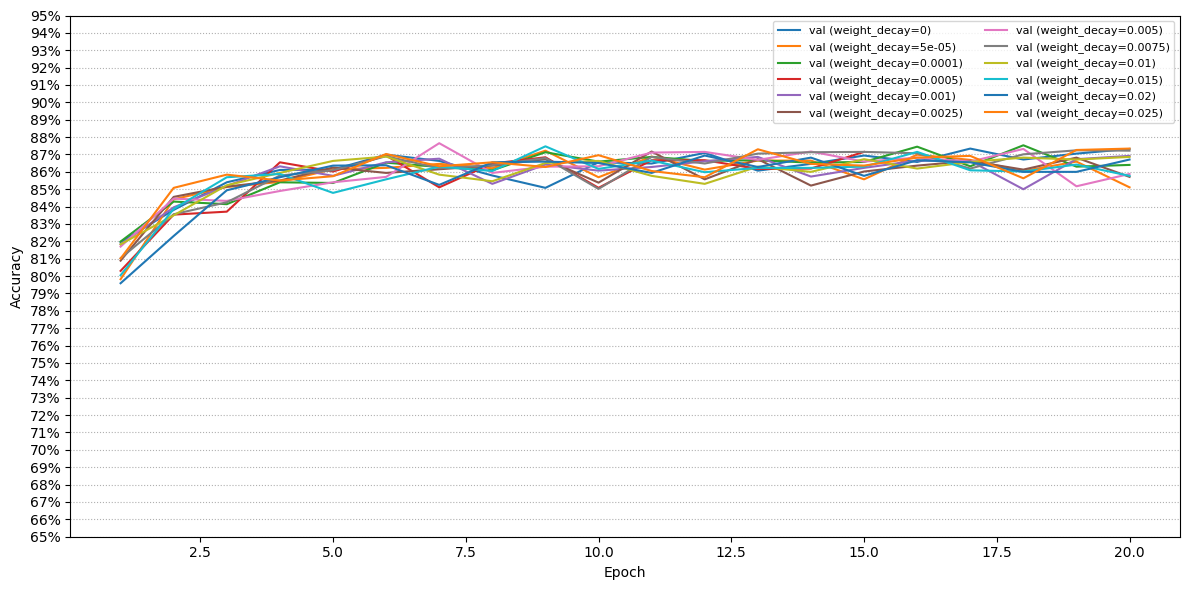

In [3]:
# Parse your log text into a tidy DataFrame, then plot train/val accuracy per epoch
# Y-axis shows only 65%..95% with 1% tick labels.

import re
from typing import List, Dict, Optional

import pandas as pd
import matplotlib.pyplot as plt


def parse_training_logs(log_text: str) -> pd.DataFrame:
    """
    Returns a DataFrame with columns:
      weight_decay, learning_rate, batch_size, epoch, train_accuracy, val_accuracy
    """
    rows: List[Dict] = []

    current_batch_size: Optional[int] = None
    current_weight_decay: Optional[float] = None
    current_learning_rate: Optional[float] = None

    header_pattern = re.compile(
        r"Starting Pass,\s*batch_size=(\d+),\s*weight_decay=([0-9eE\.\-]+),\s*learning_rate=([0-9eE\.\-]+)"
    )

    # Example epoch line:
    # @ lr = 0.00002800, batch = 12, w_decay = 0.00000000, epoch 01 | tr 1.0179/0.6622 | va 0.5727/0.8195 | ...
    epoch_pattern = re.compile(
        r"@.*?epoch\s+(\d+)\s*\|\s*tr\s+([0-9eE\.\-]+)/([0-9eE\.\-]+)\s*\|\s*va\s+([0-9eE\.\-]+)/([0-9eE\.\-]+)"
    )

    for raw_line in log_text.splitlines():
        line = raw_line.strip()
        if not line:
            continue

        header_match = header_pattern.search(line)
        if header_match:
            current_batch_size = int(header_match.group(1))
            current_weight_decay = float(header_match.group(2))
            current_learning_rate = float(header_match.group(3))
            continue

        epoch_match = epoch_pattern.search(line)
        if epoch_match and current_weight_decay is not None:
            epoch = int(epoch_match.group(1))

            # losses are group(2) and group(4) if you ever want them
            train_accuracy = float(epoch_match.group(3))
            val_accuracy = float(epoch_match.group(5))

            rows.append(
                {
                    "batch_size": current_batch_size,
                    "weight_decay": current_weight_decay,
                    "learning_rate": current_learning_rate,
                    "epoch": epoch,
                    "train_accuracy": train_accuracy,
                    "val_accuracy": val_accuracy,
                }
            )

    if not rows:
        raise ValueError("No epoch rows parsed. Check the patterns vs your log format.")

    df = pd.DataFrame(rows).sort_values(["weight_decay", "epoch"]).reset_index(drop=True)
    return df


def plot_accuracy_curves(
    df: pd.DataFrame,
    *,
    learning_rate: Optional[float] = None,
    batch_size: Optional[int] = None,
    y_min: float = 0.65,
    y_max: float = 0.95,
) -> None:
    """
    Plots train/val accuracy vs epoch for each weight_decay.
    If learning_rate or batch_size are provided, filters to those values.
    """
    plot_df = df.copy()

    if learning_rate is not None:
        plot_df = plot_df[plot_df["learning_rate"] == learning_rate]

    if batch_size is not None:
        plot_df = plot_df[plot_df["batch_size"] == batch_size]

    if plot_df.empty:
        raise ValueError("No rows left after filtering. Remove filters or check values.")

    # One figure: all weight_decay runs together (train + val for each).
    plt.figure(figsize=(12, 6))

    for weight_decay_value in sorted(plot_df["weight_decay"].unique()):
        run_df = plot_df[plot_df["weight_decay"] == weight_decay_value].sort_values("epoch")

        plt.plot(
            run_df["epoch"],
            run_df["val_accuracy"],
            label=f"val (weight_decay={weight_decay_value:g})",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    # Clamp y-axis to 65%..95%
    plt.ylim(y_min, y_max)

    # 1% tick labels
    ticks = [x / 100.0 for x in range(int(y_min * 100), int(y_max * 100) + 1)]
    plt.yticks(ticks, [f"{int(t * 100)}%" for t in ticks])

    plt.grid(True, which="both", axis="y", linestyle=":", linewidth=0.8)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


# ----------------------------
# Usage
# ----------------------------
# Put your giant string in `logs` exactly like you already have it:
# logs = """ ... """

df = parse_training_logs(logs)

# Optional: peek at parsed data
display(df.head(10))

# Plot all runs (all weight_decay values found)
plot_accuracy_curves(df)

# Or filter to a specific learning_rate/batch_size if needed:
# plot_accuracy_curves(df, learning_rate=2.8e-05, batch_size=12)